In [1]:
from tensorflow.keras.layers import Conv2D,MaxPooling2D,Dense,Flatten
import numpy as np

In [2]:
from tensorflow.keras.models import Sequential

# importing data base 

In [5]:
X_train = np.loadtxt('input.csv',delimiter=',')
Y_train =  np.loadtxt('labels.csv',delimiter=',')

X_test = np.loadtxt('input_test.csv',delimiter=',')
Y_test = np.loadtxt('labels_test.csv',delimiter=',')

In [6]:
print(X_train.shape)
print(Y_train.shape)
print(X_test.shape)
print(Y_test.shape)


(2000, 30000)
(2000,)
(400, 30000)
(400,)


# cleaning the data

In [9]:
X_train = X_train.reshape(len(X_train),100,100,3)
Y_train = Y_train.reshape(len(Y_train),1)

X_test = X_test.reshape(len(X_test),100,100,3)
Y_test = Y_test.reshape(len(Y_test),1)

In [10]:
print(X_train.shape)
print(Y_train.shape)
print(X_test.shape)
print(Y_test.shape)


(2000, 100, 100, 3)
(2000, 1)
(400, 100, 100, 3)
(400, 1)


In [11]:
X_train[:,1]

array([[[ 45.,  43.,  28.],
        [ 28.,  25.,   8.],
        [ 52.,  40.,  24.],
        ...,
        [ 54.,  41.,  32.],
        [ 57.,  43.,  34.],
        [ 61.,  47.,  38.]],

       [[140., 137., 144.],
        [127., 124., 131.],
        [120., 114., 124.],
        ...,
        [251., 253., 252.],
        [254., 255., 253.],
        [254., 255., 251.]],

       [[ 78.,  87.,  84.],
        [ 90., 101.,  95.],
        [ 79.,  90.,  82.],
        ...,
        [ 37.,  54.,  38.],
        [ 31.,  48.,  32.],
        [ 13.,  30.,  14.]],

       ...,

       [[244., 238., 242.],
        [220., 216., 217.],
        [248., 243., 240.],
        ...,
        [234., 222., 206.],
        [184., 172., 158.],
        [194., 182., 168.]],

       [[ 11.,  12.,  14.],
        [ 16.,  20.,  21.],
        [ 18.,  21.,  28.],
        ...,
        [ 66.,  70.,  71.],
        [ 61.,  65.,  68.],
        [ 59.,  63.,  64.]],

       [[ 55.,  29.,  12.],
        [ 88.,  40.,  20.],
        [178.,  

In [12]:
# making the the image value into a dsecimial value 

In [13]:
X_train = X_train/225.0
X_test = X_test/225.0

In [14]:
X_train[:,1]

array([[[0.2       , 0.19111111, 0.12444444],
        [0.12444444, 0.11111111, 0.03555556],
        [0.23111111, 0.17777778, 0.10666667],
        ...,
        [0.24      , 0.18222222, 0.14222222],
        [0.25333333, 0.19111111, 0.15111111],
        [0.27111111, 0.20888889, 0.16888889]],

       [[0.62222222, 0.60888889, 0.64      ],
        [0.56444444, 0.55111111, 0.58222222],
        [0.53333333, 0.50666667, 0.55111111],
        ...,
        [1.11555556, 1.12444444, 1.12      ],
        [1.12888889, 1.13333333, 1.12444444],
        [1.12888889, 1.13333333, 1.11555556]],

       [[0.34666667, 0.38666667, 0.37333333],
        [0.4       , 0.44888889, 0.42222222],
        [0.35111111, 0.4       , 0.36444444],
        ...,
        [0.16444444, 0.24      , 0.16888889],
        [0.13777778, 0.21333333, 0.14222222],
        [0.05777778, 0.13333333, 0.06222222]],

       ...,

       [[1.08444444, 1.05777778, 1.07555556],
        [0.97777778, 0.96      , 0.96444444],
        [1.10222222, 1

In [15]:
# displaying the image 

In [18]:
import matplotlib.pyplot as plt
import random

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.044444444444444446..1.1333333333333333].


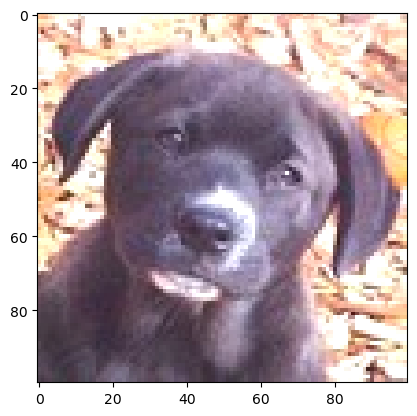

In [23]:
idx = random.randint(0,len(X_train)-1)
plt.imshow(X_train[idx])
plt.show()


# bulding a model

In [24]:
model = Sequential([
    Conv2D(32,(3,3),activation='relu',input_shape = (100,100,3)),
    MaxPooling2D((2,2)),

    Conv2D(32,(3,3),activation='relu'),
    MaxPooling2D((2,2)),


    Flatten(),
    Dense(64,activation = 'relu'),
    Dense(1,activation = 'sigmoid')

])

C:\Users\abhia\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [26]:
model.compile(loss = 'binary_crossentropy',optimizer = 'adam',metrics = (['accuracy']))

In [28]:
model.fit(X_train,Y_train,epochs=10,batch_size=64)

Epoch 1/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 74ms/step - accuracy: 0.7455 - loss: 0.5276 
Epoch 2/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 77ms/step - accuracy: 0.7900 - loss: 0.4559 
Epoch 3/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 75ms/step - accuracy: 0.8030 - loss: 0.4316 
Epoch 4/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 74ms/step - accuracy: 0.8310 - loss: 0.3768 
Epoch 5/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 74ms/step - accuracy: 0.8625 - loss: 0.3185 
Epoch 6/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 74ms/step - accuracy: 0.9060 - loss: 0.2517 
Epoch 7/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 76ms/step - accuracy: 0.9115 - loss: 0.2210 
Epoch 8/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 76ms/step - accuracy: 0.9395 - loss: 0.1715 
Epoch 9/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 77ms/step - accuracy: 0.9565 - loss: 0.1387 
Epoch 10/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 74ms/step - accuracy: 0.9695 - loss: 0.1065 


In [29]:
model.evaluate(X_test,Y_test)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6700 - loss: 0.9095 


[0.9095154404640198, 0.6700000166893005]

# making prediction 

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.1333333333333333].


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
[[0.9999096]]
IT IS A CAT


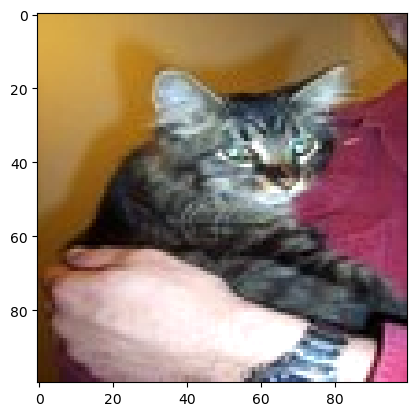

In [35]:
idx2 = random.randint(0,len(X_test)-1)
plt.imshow(X_test[idx2])
plt.show

y_predict = model.predict(X_test[idx2,:].reshape(1,100,100,3))
print(y_predict)

y_predict =   y_predict > 0.5

if y_predict==0 :
    print("IT IS A DOG ")
else :
    print("IT IS A CAT")

